# CUSTOMER SEGMENTATION AND RECOMMENDATION SYSTEM USING K-MEANS CLUSTERING PROJECT

# 1. PROJECT INTRODUCTION

 Customer Segmentation and Recommendation System Using K-Means Clustering is an advanced Data Science project that focuses on analyzing customer purchasing behavior and dividing customers into meaningful groups.

    
 In this project, K-Means Clustering is used to identify different customer segments based on their purchasing patterns. RFM Analysis (Recency, Frequency, and Monetary) is used to understand customer behavior, while the recommendation component can be used to suggest relevant products based on customer preferences.

    
 Project Objectives

 Analyze customer purchasing behavior.

 Perform data cleaning and preprocessing.

 Calculate Recency, Frequency, and Monetary values.

 Apply feature engineering and data standardization.

 Determine the optimal number of customer clusters.

 Apply the K-Means clustering algorithm.


 Visualize and interpret different customer segments.

 Generate useful business insights.

 Build a basic customer recommendation system.

 Technologies Used

 Python

 Pandas

 NumPy
    
 Matplotlib

 Seaborn

 Scikit-learn

 Jupyter Notebook

# 2. Import Required Libraries

In [2]:
# Importing Pandas for data manipulation and analysis
import pandas as pd

# Importing Numpy for numerical calculations
import numpy as np

# Importing matplotlib for data visualization
import matplotlib.pyplot as plt

# Importing Seaborn for advanced statistical visualizations
import seaborn as sns

# Importing StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Importing KMeans for customer segmentation using clustering
from sklearn.cluster import KMeans

# Importing silhouette_score to evaluate the quality of clusters
from sklearn.metrics import silhouette_score

# Importing warnings to control unnecessary warning messages
import warnings

# Ignoring warning messages to keep the notebook output clean
warnings.filterwarnings("ignore")

# Print message confirmation
print("All libraries are imported")

All libraries are imported


# 3. Check Library Versions

In [3]:
# Checking the Pandas version
print("Pandas Version:", pd.__version__)

# Checking the Numpy version
print("Numpy Version:", np.__version__)

# Checking the Mathplotlib version
print("Matplotlib Version:", plt.matplotlib.__version__)

# Checking the Seaborn version
print("Seaborn Version:", sns.__version__)

Pandas Version: 2.3.3
Numpy Version: 2.3.5
Matplotlib Version: 3.10.6
Seaborn Version: 0.13.2


# 4. Loading the Dataset

In [5]:
# Loading the Online Retail dataset 
df = pd.read_csv("OnlineRetail.csv", encoding="latin1")

# Displaying the dataset
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


# DATA UNDERSTANDING

# 5. Display First 5 Rows

In [6]:
# Displaying the first five rows the dataset
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# 6. Display Last 5 Rows

In [7]:
# Displaying the last five rows of the dataset
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


# 7. Check Dataset Shape

In [8]:
# Checking the number of rows and columns in the dataset
df.shape

(541909, 8)

# 8. Check Column Names

In [10]:
# Displaying all column names in the dataset
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

# 9. Check Data Types

In [11]:
# Displaying the dataset type of  each column
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

# 10. Detailed Dataset Information

In [12]:
# Displaying dataset information including columns, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# 11. Statistical Summary

In [13]:
# Generating statistical summary for numerical columns
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


# 12. Check Missing Values

In [14]:
# Checking the number of missing values in each column
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

# 13. Check Duplicate Records

In [15]:
# Checking the total number of duplicate records
df.duplicated().sum()

np.int64(5268)

# 14. Check Unique Values

In [16]:
# Checking the number of unique values in each column
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

#  15. Check Unique Countries

In [17]:
# Displaying the number of unique countries in the dataset
df["Country"].nunique()

38

# 16. Display Top Countries

In [18]:
# Displaying the top 10 countries based on number of transactions
df["Country"].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

# 17. Check Unique Customers

In [19]:
# Counting the total number of unique customers
df["CustomerID"].nunique()

4372

# 18. Check Unique Products

In [20]:
# Counting the total number of unique products
df["StockCode"].nunique()

4070

# DATA CLEANING

# 19. Handling Missing CustomerIDs

In [21]:
# Checking missing values in CustomerID
df["CustomerID"].isnull().sum()

np.int64(135080)

In [22]:
# Removing rows where CustomerID id missing
df = df.dropna(subset=["CustomerID"])

# Checking the updated dataset shape
df.shape

(406829, 8)

# 20. Remove Duplicate Records 

In [23]:
# Checking the number of duplicate records
df.duplicated().sum()

np.int64(5225)

In [24]:
# Removing duplicate records
df = df.drop_duplicates()

# Checking the updated dataset shape 
df.shape

(401604, 8)

# 21. Check Negative Quantities

In [25]:
# Checking transactions with negative quantities
(df["Quantity"]<0).sum()

np.int64(8872)

# 22. Remove Negative Quantities

In [26]:
# Keeping only transactions with positive quantities
df = df[df["Quantity"]>0]

# Checking the updated dateset shape 
df.shape

(392732, 8)

# 23. Check Invalid Unit Prices

In [27]:
# Checking transactions with zero or negative unit prices
(df["UnitPrice"]<=0).sum()

np.int64(40)

# 24. Remove Invalid Unit Prices

In [28]:
# Keeping only transactions with positive unit prices
df = df[df["UnitPrice"]>0]

# Checking the updated dataset shape
df.shape

(392692, 8)

# 25. Convert CustomerID to Integer

In [30]:
# Converting CustomerID from float to integer
df["CustomerID"] = df["CustomerID"].astype(int)

# Checking the updated data types
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID       int64
Country         object
dtype: object

# 26. Convert InvoiceData to Datetime

In [31]:
# Converting InvoiceData into Datetime format
df["Invoice Date"] = pd.to_datetime(df["InvoiceDate"])

# Checking the date type of InvoiceDate
df["InvoiceDate"].dtypes

dtype('O')

# 27. Final Missing Value Check

In [32]:
# Checking missing values after data cleaning
df.isnull().sum()

InvoiceNo       0
StockCode       0
Description     0
Quantity        0
InvoiceDate     0
UnitPrice       0
CustomerID      0
Country         0
Invoice Date    0
dtype: int64

# 28. Final Dataset Information

In [33]:
# Displaying the final information of the cleaned dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   InvoiceNo     392692 non-null  object        
 1   StockCode     392692 non-null  object        
 2   Description   392692 non-null  object        
 3   Quantity      392692 non-null  int64         
 4   InvoiceDate   392692 non-null  object        
 5   UnitPrice     392692 non-null  float64       
 6   CustomerID    392692 non-null  int64         
 7   Country       392692 non-null  object        
 8   Invoice Date  392692 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(2), object(5)
memory usage: 30.0+ MB


# 29. Display Cleaned Dataset

In [34]:
# Displaying the first five rows of the cleaned dataset
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Invoice Date
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom,2010-12-01 08:26:00
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom,2010-12-01 08:26:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom,2010-12-01 08:26:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom,2010-12-01 08:26:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom,2010-12-01 08:26:00


# EXPLORATORY DATA ANALYSIS (EDA)

# 30. Monthly Sales Analysis

In [40]:
# Creating a new column for total sales
df["TotalSales"] = df["Quantity"]*df["UnitPrice"]

# Extracting month and year from InvoiceDate
df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)

# Calculating total sales for each month
monthly_sales = df.groupby("Month")["TotalSales"].sum()

# Displaying monthly sales
monthly_sales

Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Name: TotalSales, dtype: float64

# 31. Monthly Sales Visualization 

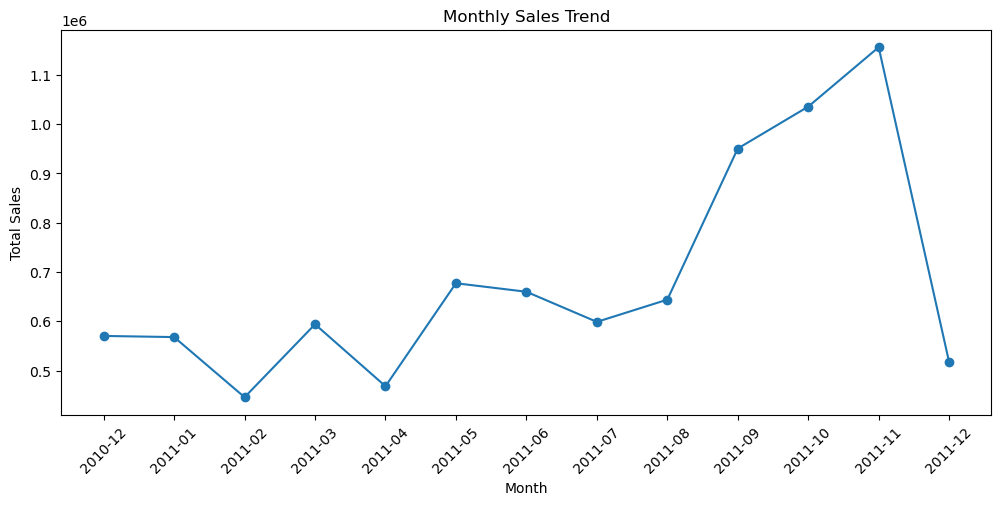

In [41]:
# Creating a line chart for monthly sales
plt.figure(figsize=(12,5))

# Plotting monthly sales
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

# Adding chart title and labels
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

# Rotating x-axis labels for better readability
plt.xticks(rotation=45)

# Displaying the chart
plt.show()

# 32. Top 10 Countries by Sales

In [42]:
# Calculating total sales for each country
country_sales =  df.groupby("Country")["TotalSales"].sum().sort_values(ascending = False)

# Selecting the top 10 countries
top_countries = country_sales.head(10)

#  Displaying the top 10 countries
top_countries

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalSales, dtype: float64

# 33. Top Countries Visualization

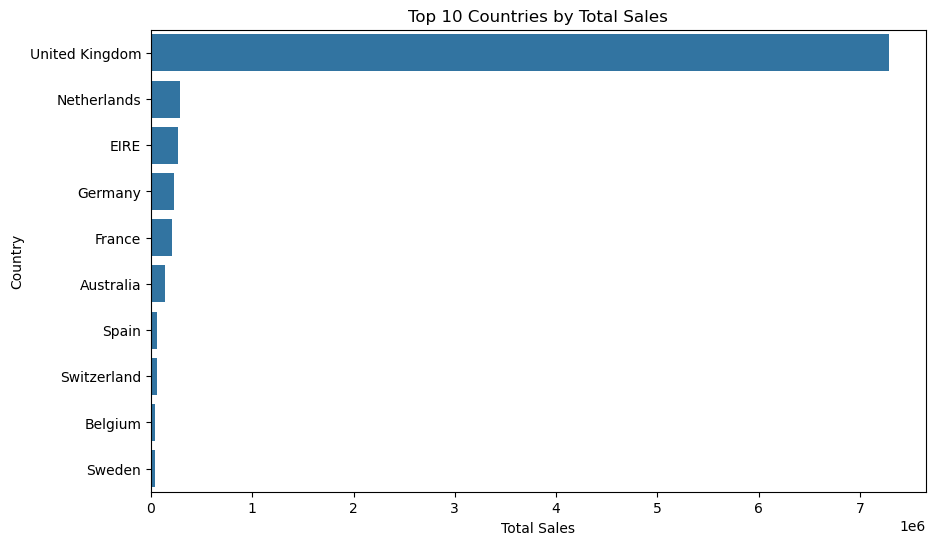

In [44]:
# Creating a bar chart for the top 10 countries by sales
plt.figure(figsize=(10,6))

# Plotting the top countries
sns.barplot(x=top_countries.values, y=top_countries.index)

# Adding chart title and labels
plt.title("Top 10 Countries by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Country")

# Displaying the chart
plt.show()

# 34. Top 10 Products by Quantity Sold

In [45]:
# Calculating total quantity sold for each product
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

# Displaying the top 10 products
top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

# 35. Top Products Visualization

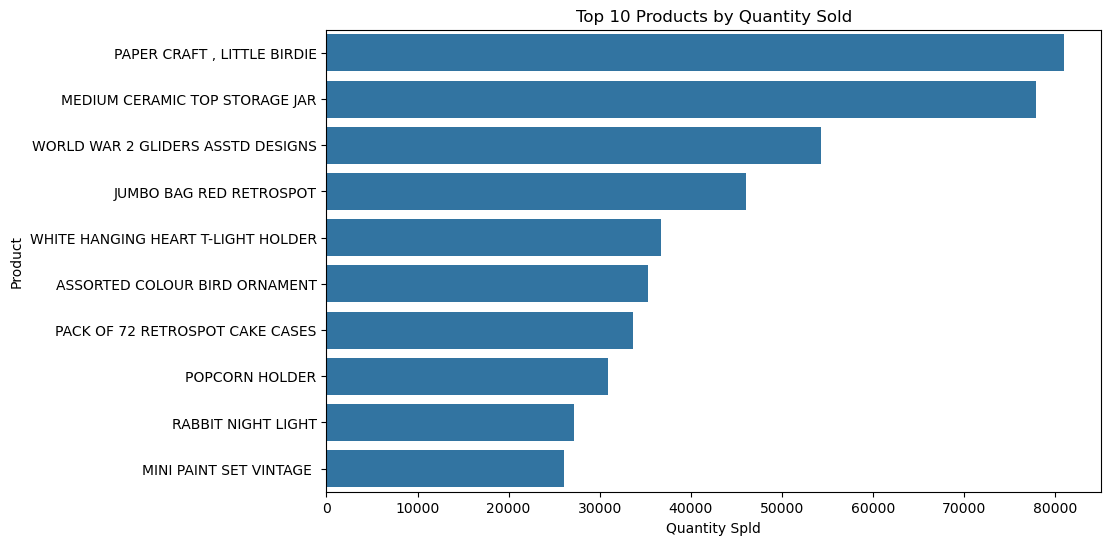

In [46]:
# Creating a horizontal bar chart for the top 10 products
plt.figure(figsize=(10,6))

# Plotting the top products
sns.barplot(x=top_products.values, y=top_products.index)

# Adding chart title and labels
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Spld")
plt.ylabel("Product")

# Displaying the chart 
plt.show()

# 36. Customer Purchase Distribution

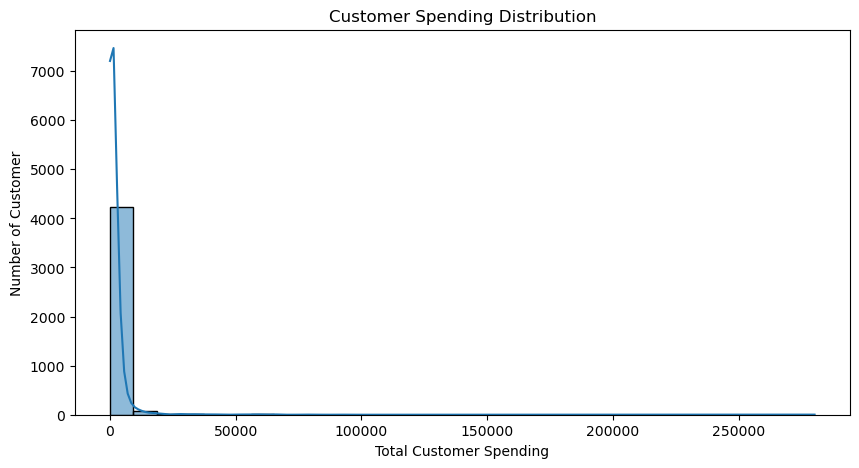

In [49]:
# Calculating total spending for each customer
customer_sales = df.groupby("CustomerID")["TotalSales"].sum()

# Creating a histogram of customer spending
plt.figure(figsize=(10,5))

#Plotting the distribution
sns.histplot(customer_sales, bins=30, kde=True)

# Adding chart title and labels
plt.title("Customer Spending Distribution")
plt.xlabel("Total Customer Spending")
plt.ylabel("Number of Customer")

# Displaying the chart
plt.show()

# 37. Quantity vs Unit Price

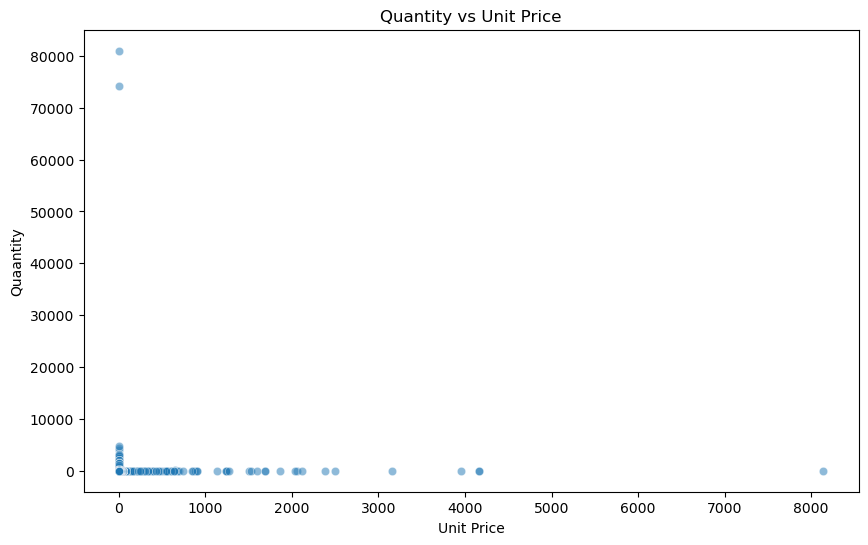

In [50]:
# Creating a scatter plot between quantity and unit price
plt.figure(figsize=(10,6))

# Plotting the relationship
sns.scatterplot(data=df, x="UnitPrice", y="Quantity", alpha=0.5)

# Adding chart title and labels
plt.title("Quantity vs Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Quaantity")

# Displaying the chart
plt.show()

# RECENCY FREQUENCY MONETARY (RFM) Analysis

# 38. Set Analysis Date

In [51]:
# Finding the latest transaction data in the dataset
latest_date = df["InvoiceDate"].max()

# Displaying the latest transaction date
print("Latest Transaction Date:", latest_date)

Latest Transaction Date: 2011-12-09 12:50:00


# 39. Calculate RFM Values

In [53]:
# Calculating RFM metrics for each customer
rfm = df.groupby("CustomerID").agg({"InvoiceDate": lambda x:(latest_date - x.max()).days, "InvoiceNo": "nunique", "TotalSales": "sum"})

# Renaming the columns
rfm.rename(columns={"InvoiceDate": "Recency", "InvoiceNo": "Frequency", "TotalSales": "Monetary"}, inplace=True)

# Displaying the first five customers
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,325,1,77183.60
12347,1,7,4310.00
12348,74,4,1797.24
12349,18,1,1757.55
12350,309,1,334.40


# 40. Check RFM Dataset

In [54]:
# Checking the shape of the RFM dataset
rfm.shape

(4338, 3)

In [55]:
# 41. Checking statistical summary of RFM features
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,306.482500
50%,50.000000,2.000000,668.570000
75%,141.000000,5.000000,1660.597500
max,373.000000,209.000000,280206.020000


# 41. Check Missing Values

In [56]:
# Checking missing values in RFM data
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

# 42. RFM Distribution

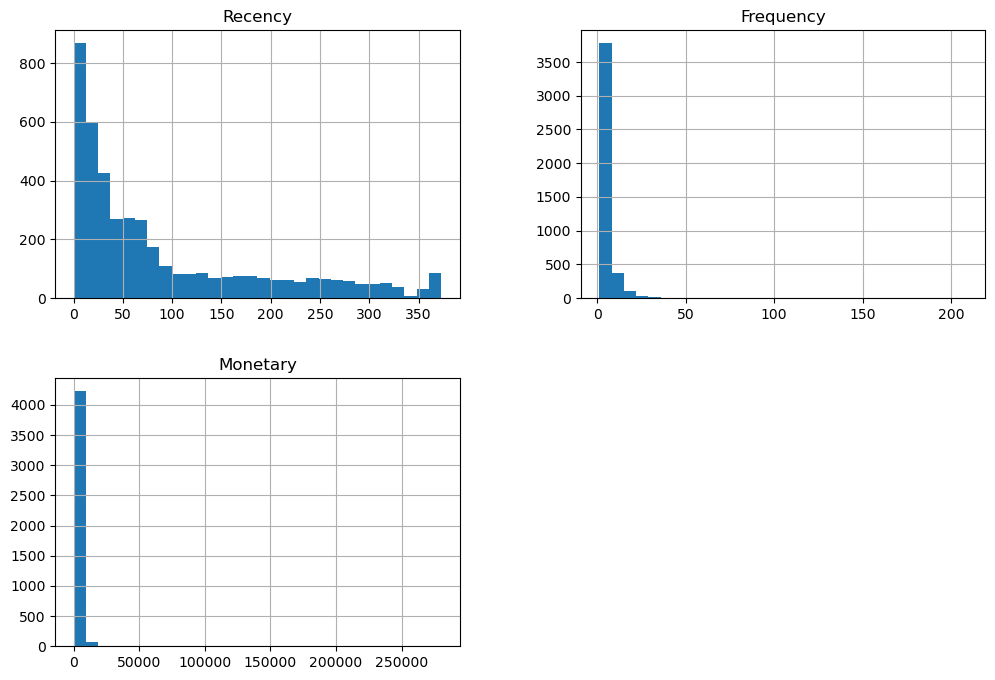

In [57]:
# Creating histograms for RFM features
rfm[["Recency", "Frequency", "Monetary"]].hist(figsize=(12,8), bins=30)

# Displaying the plots
plt.show()

# RFM FEATUTRE ANALYSIS & SCALING

# 43. Check RFM Features

In [58]:
# Displaying the RFM features 
rfm[["Recency", "Frequency", "Monetary"]].head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,325,1,77183.60
12347,1,7,4310.00
12348,74,4,1797.24
12349,18,1,1757.55
12350,309,1,334.40


# 44. Check RFM Statistics

In [59]:
# Displaying statistical summary of RFM features
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,306.482500
50%,50.000000,2.000000,668.570000
75%,141.000000,5.000000,1660.597500
max,373.000000,209.000000,280206.020000


# 45 Visualize RFM Features

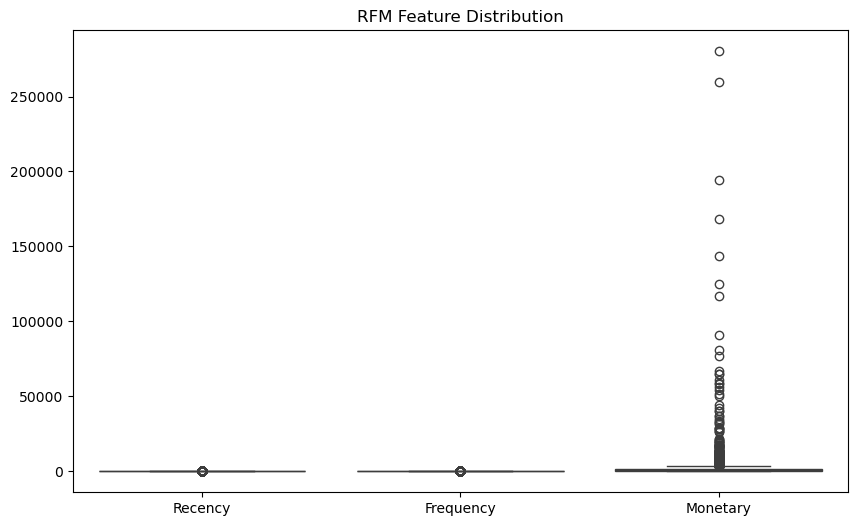

In [63]:
# Creating boxplots to identify the distribution and potential outliers
plt.figure(figsize=(10,6))

# Plotting the rfm features
sns.boxplot(data=rfm[["Recency", "Frequency", "Monetary"]])

# Adding chart title
plt.title("RFM Feature Distribution")

# Displaying the chart
plt.show()

# 46. Select Features for Clustering

In [62]:
# Selecting RFM features for customer segmentation
rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

# 47. Standardize RFM Features

In [65]:
# Creating a standardScaler object 
scaler = StandardScaler()

# Scaling the RFM features
rfm_scaled = scaler.fit_transform(rfm_features)

# Converting scaled data into a DataFrame
rfm_scaled = pd.DataFrame(rfm_scaled, columns=["Recency", "Frequency", "Monetary"], index=rfm.index)

# Displaying the first five scaled records
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,2.334574,-0.425097,8.363010
12347,-0.905340,0.354417,0.251699
12348,-0.175360,-0.035340,-0.027988
12349,-0.735345,-0.425097,-0.032406
12350,2.174578,-0.425097,-0.190812


# 48. Check Scaled Data

In [66]:
# Checking the mean and standard deviation of scaled features
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,2.702618e-17,1.801745e-17,2.293130e-17
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.153401e-01,-4.250965e-01,-2.276151e-01
25%,-7.453445e-01,-4.250965e-01,-1.939190e-01
50%,-4.153533e-01,-2.951776e-01,-1.536162e-01
75%,4.946227e-01,9.457903e-02,-4.319704e-02
max,2.814561e+00,2.659803e+01,3.096074e+01


#  FINDING THE OPTIMAL NUMBER OF CLUSTERS USING THE ELBOW METHOD

# 49. Calculate WCSS

In [73]:
# Calculating WCSS for different numbers of clusters
wcss = []

for k in [2,3,4,5,6,7,8,9,10]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    
    wcss.append(kmeans.inertia_)

print("WCSS Values:")
print(wcss)

print("Number of WCSS values:", len(wcss))

WCSS Values:
[9014.56627957298, 5441.323586829658, 4096.300210662245, 3119.7898598001484, 2473.7933635647596, 2023.5866272235492, 1717.0110430839172, 1468.7871021842966, 1281.0480511013268]
Number of WCSS values: 9


# 50. Elbow Method Visualization

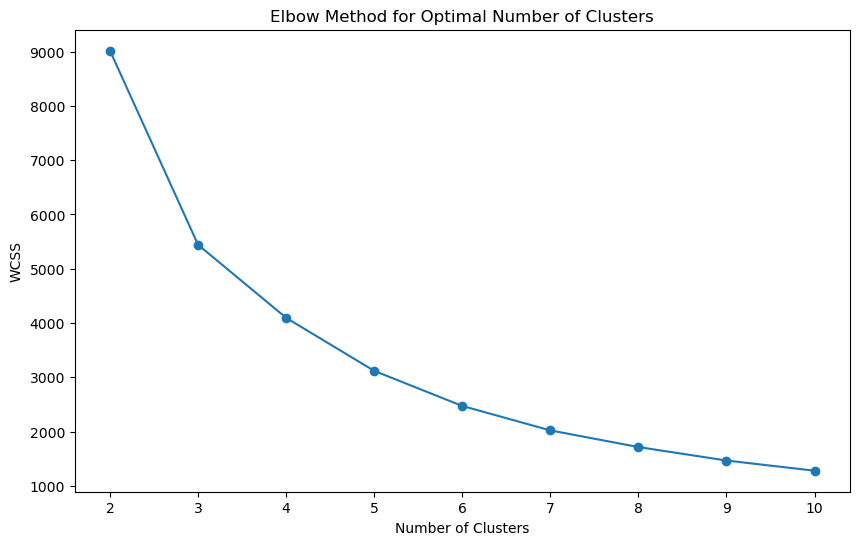

In [74]:
# Creating the Elbow Method Plot 
plt.figure(figsize=(10,6))

# Plotting the number of clusters against WCSS
plt.plot([2,3,4,5,6,7,8,9,10], wcss, marker="o")

# Adding chart title
plt.title("Elbow Method for Optimal Number of Clusters")

# Adding x-axis label
plt.xlabel("Number of Clusters")

# Adding y-axis label
plt.ylabel("WCSS")

# Displaying the chart
plt.show()

In [75]:
# Displaying cluster numbers and their WCSS values
for k , value in zip(range(2,11), wcss):
    print("Cluster:", k, "WCSS:", value)

Cluster: 2 WCSS: 9014.56627957298
Cluster: 3 WCSS: 5441.323586829658
Cluster: 4 WCSS: 4096.300210662245
Cluster: 5 WCSS: 3119.7898598001484
Cluster: 6 WCSS: 2473.7933635647596
Cluster: 7 WCSS: 2023.5866272235492
Cluster: 8 WCSS: 1717.0110430839172
Cluster: 9 WCSS: 1468.7871021842966
Cluster: 10 WCSS: 1281.0480511013268


# 51. Silhouette Score

In [81]:
# Creating a dictionary to store silhouette score
silhouette_scores = {}

# Testing different numbers to clusters from 2 to 10
for k in range(2,11):

    # Creating the K-Means model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    # Predicting cluster labels 
    labels = kmeans.fit_predict(rfm_scaled)

    # Calculating the silhouette score
    score = silhouette_score(rfm_scaled, labels)

    # Storing the score
    silhouette_scores[k] = score

# Displaying silhouette scores
for k, score in silhouette_scores.items():
    print("Cluster:", k, "Silhouette Score:", score)

Cluster: 2 Silhouette Score: 0.8958249711727472
Cluster: 3 Silhouette Score: 0.5942233320872992
Cluster: 4 Silhouette Score: 0.6162275299061803
Cluster: 5 Silhouette Score: 0.6165002474679847
Cluster: 6 Silhouette Score: 0.5982885618366588
Cluster: 7 Silhouette Score: 0.516531562964477
Cluster: 8 Silhouette Score: 0.4858735340682143
Cluster: 9 Silhouette Score: 0.4784383467130572
Cluster: 10 Silhouette Score: 0.4792443643654188


# 52. Silhouette Score Visualization

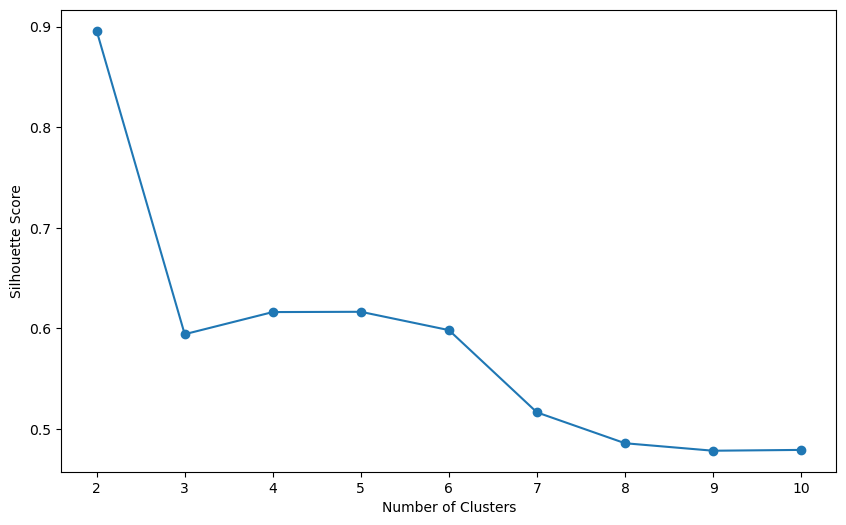

In [82]:
# Creating the silhouette score visualization
plt.figure(figsize=(10,6))

# Plotting cluster numbers against silhouette scores
plt.plot(list(silhouette_scores.keys()),
         list(silhouette_scores.values()),
         marker="o")

# Adding x-axis label
plt.xlabel("Number of Clusters")

# Adding y-axis label
plt.ylabel("Silhouette Score")

# Displaying the graph
plt.show()

# K-MEANS CLUSTERING & CUSTOMER SEGMENTATION

# 53. Build K-Means Model

In [83]:
# Setting the optimal number of clusters
optimal_k = 5

# Creating the K-Means clusting model
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Fitting the K-Means model and assigning cluster labels
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

# Displaying the first five customer clusters
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,325,1,77183.60,3
12347,1,7,4310.00,0
12348,74,4,1797.24,0
12349,18,1,1757.55,0
12350,309,1,334.40,1


# 54. Check Number of Customers in Each Cluster

In [84]:
# Counting the number of customers in each cluster
cluster_counts = rfm["Cluster"].value_counts().sort_index()

# Displaying the number of customers in each cluster
cluster_counts

Cluster
0    3048
1    1063
2       8
3     213
4       6
Name: count, dtype: int64

# 55. Visualize Customer Clusters

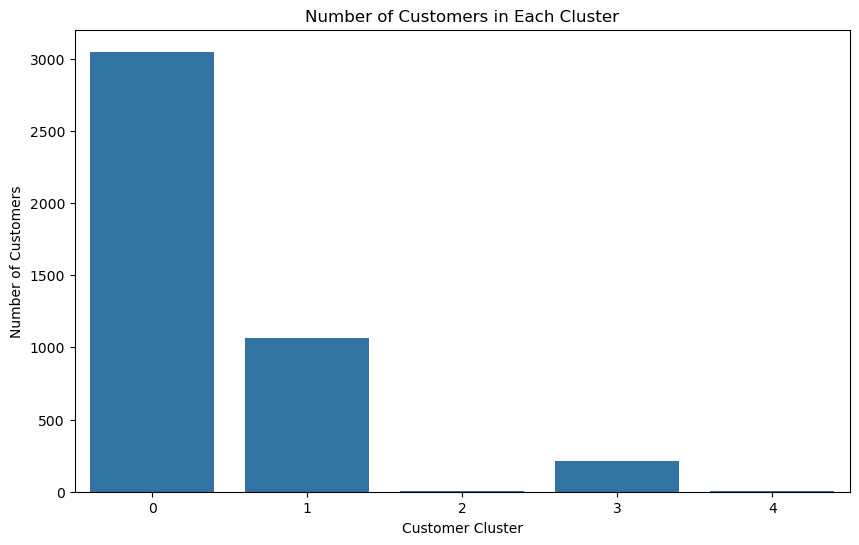

In [85]:
# Creating a bar chart for the number of customers in each cluster
plt.figure(figsize=(10,6))

# Plotting customer count each cluster
sns.barplot(x=cluster_counts.index, y=cluster_counts.values)

# Adding chart title
plt.title("Number of Customers in Each Cluster")

# Adding x-axis label
plt.xlabel("Customer Cluster")

# Adding y-axis label
plt.ylabel("Number of Customers")

# Displaying the chart
plt.show()

# 56. Analyze Cluster Characteristics

In [86]:
# Calculating average RFM values for each customer cluster
cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

# Displaying cluster characteristics
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,42.918635,3.650262,1333.132908
1,247.469426,1.553151,478.648242
2,5.500000,120.500000,55099.491250
3,14.671362,21.286385,12813.941596
4,6.666667,42.833333,190808.536667


# 57. Visualize Cluster Characteristics

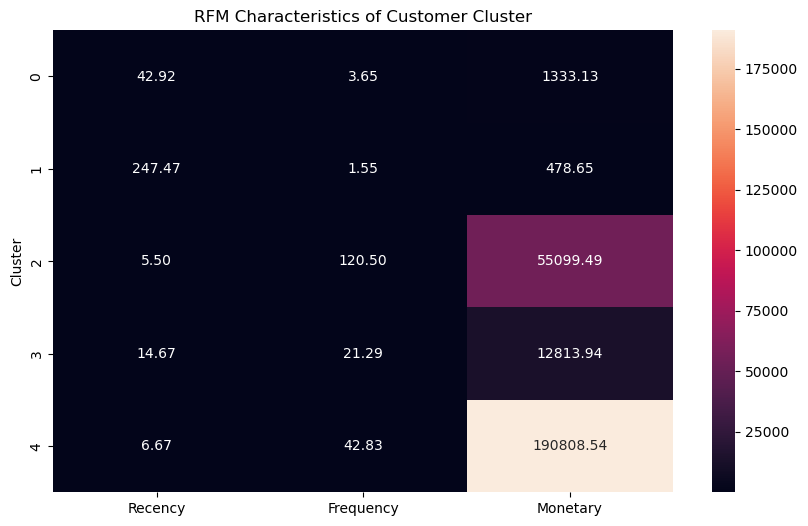

In [87]:
# Creating a heatmap to compare RFM values across clusters
plt.figure(figsize=(10,6))

# Plotting the cluster summary
sns.heatmap(cluster_summary, annot=True, fmt=".2f")

# Adding chart tilte
plt.title("RFM Characteristics of Customer Cluster")

# Displaying the chart
plt.show()

# CLUSTER EVALUATION

# 58. Calculate Silhouette Score

In [88]:
# Calculating the silhouette score for the final K-Means  model
silhouette_avg = silhouette_score(rfm_scaled, rfm["Cluster"])

# Displaying the silhouette score
print("Silhouette Score:", silhouette_avg)

Silhouette Score: 0.6165002474679847


# 59. Calculate Final WCSS 

In [89]:
# Calculating the final WCSS value for the selected number of clusters
final_wcss = kmeans.inertia_

# Displaying the final WCSS
print("Final WCSS:", final_wcss)

Final WCSS: 3119.7898598001484


# 60. Display Cluster Summary

In [90]:
# Displaying the average RFM values for each cluster
cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

# Displaying the cluster summary
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,42.918635,3.650262,1333.132908
1,247.469426,1.553151,478.648242
2,5.500000,120.500000,55099.491250
3,14.671362,21.286385,12813.941596
4,6.666667,42.833333,190808.536667


# 61. Compare Cluster Sizes

In [91]:
# Counting customers in each cluster 
cluster_size = rfm["Cluster"].value_counts().sort_index()

# Displaying cluster sizes
print("Customers in Each Cluster:")
print(cluster_size)

Customers in Each Cluster:
Cluster
0    3048
1    1063
2       8
3     213
4       6
Name: count, dtype: int64


# CUSTOMER SEGMENT ANALYSIS & CLUSTER NAMING

# 62. Diaplay Cluster Summary

In [92]:
#  Calculating the average RFM values for each cluster
cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

# Displaying the cluster summary
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,42.918635,3.650262,1333.132908
1,247.469426,1.553151,478.648242
2,5.500000,120.500000,55099.491250
3,14.671362,21.286385,12813.941596
4,6.666667,42.833333,190808.536667


# 63. Create Customer Segment Labels

In [93]:
# Creating a copy of the cluster summary for analysis
segment_summary = cluster_summary.copy()

# Displaying the cluster summary
print(segment_summary)

            Recency   Frequency       Monetary
Cluster                                       
0         42.918635    3.650262    1333.132908
1        247.469426    1.553151     478.648242
2          5.500000  120.500000   55099.491250
3         14.671362   21.286385   12813.941596
4          6.666667   42.833333  190808.536667


# 64. Automatically Identify Customer Segments

In [104]:
# Creating a function to assign meaningful customer segmennts
def assign_segment(row):

    # Identifying high-value customers
    if row["Frequency"]>=cluster_summary["Frequency"].median() and row["Monetary"]>=cluster_summary["Monetary"].median() and row["Recency"]<=cluster_summary["Recency"].median():
       return "VIP Customers"

        # Identifying customers with high purchase frequency
    elif row["Frequency"]>=cluster_summary["Frequency"].median():
        return "Loyal Customers"

        # Identifying customers with high monetary value
    elif row["Monetary"]>=cluster_summary["Monetary"].median():
        return "Potential Customers"

        # Identifying recently active customer
    elif row["Recency"]<=cluster_summary["Recency"].median():
        return "Recent Customers"

        # Remaining customers
    else:
        return "At-Risk Customers"

# Applying segment labels to each cluster
segment_summary["Segment"] = segment_summary.apply(assign_segment, axis=1)

# Displaying the final segment summary
segment_summary

,Recency,Frequency,Monetary,Segment
Cluster,,,,
0,42.918635,3.650262,1333.132908,At-Risk Customers
1,247.469426,1.553151,478.648242,At-Risk Customers
2,5.500000,120.500000,55099.491250,VIP Customers
3,14.671362,21.286385,12813.941596,VIP Customers
4,6.666667,42.833333,190808.536667,VIP Customers


# 65. Add Segment Names to Customer Data

In [105]:
# Creating a mapping between cluster numbers and segment names
cluster_to_segment = segment_summary["Segment"].to_dict()

# Adding meaningful segment names to the customer dataset
rfm["CustomerSegment"] = rfm["Cluster"].map(cluster_to_segment)

# Displaying customer segments 
rfm.head()

,Recency,Frequency,Monetary,Cluster,CustomerSegment
CustomerID,,,,,
12346,325,1,77183.60,3,VIP Customers
12347,1,7,4310.00,0,At-Risk Customers
12348,74,4,1797.24,0,At-Risk Customers
12349,18,1,1757.55,0,At-Risk Customers
12350,309,1,334.40,1,At-Risk Customers


# 66. Count Customers by Segment

In [106]:
# Counting customers in each segment 
segment_counts = rfm["CustomerSegment"].value_counts()

# Displaying the number of customers in each segment
segment_counts

CustomerSegment
At-Risk Customers    4111
VIP Customers         227
Name: count, dtype: int64

# 67. Segment Visualization

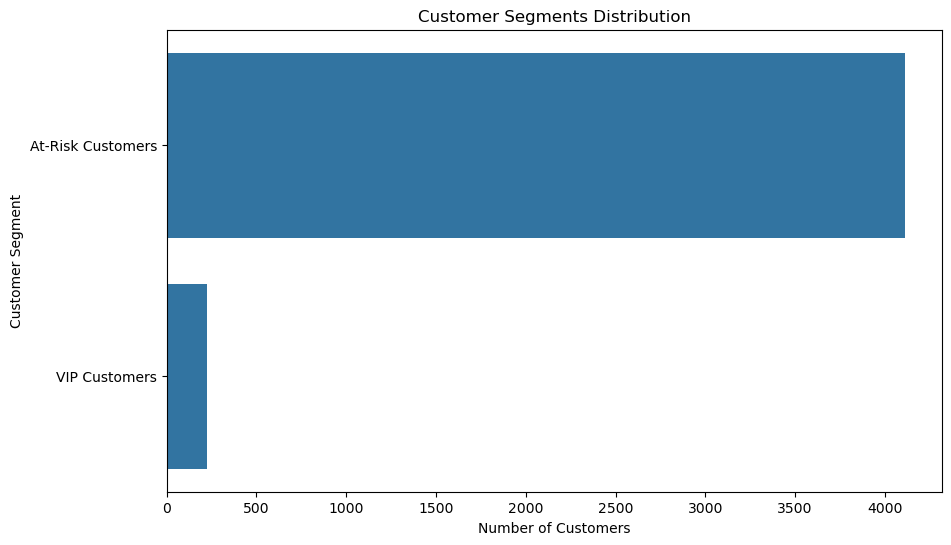

In [108]:
# Creating a bar chart for customer segments
plt.figure(figsize=(10,6))

# Plotting the number of customers in each segment
sns.barplot(x=segment_counts.values, y=segment_counts.index)

# Adding chart title 
plt.title("Customer Segments Distribution")

# Addoing x-axis label
plt.xlabel("Number of Customers")

# Adding y-axis label
plt.ylabel("Customer Segment")

# Displaying the chart
plt.show()

# 3D CUSTOMER CLUSTER VISUALIZATION

# 68. Import 3D Visualization Toolkit

In [110]:
# Importing Axes 3D for creating 3D plots
from mpl_toolkits.mplot3d import Axes3D

# Print the message confirmation
print("Library is imported")

Library is imported


# 69. Create 3D Cluster Visualization

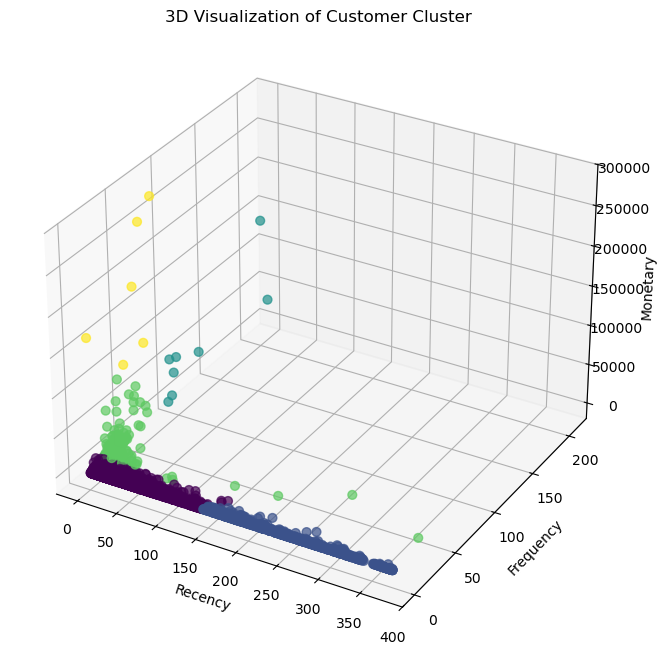

In [111]:
# Creating a 3D figure
fig = plt.figure(figsize=(12,8))

# Adding a 3D axis
ax = fig.add_subplot(111, projection="3d")

# Creating the 3D scatter plot
scatter = ax.scatter(
    rfm["Recency"], rfm["Frequency"], rfm["Monetary"], c=rfm["Cluster"], s=40, alpha=0.7)

# Adding axis labels
ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")

# Adding chart title
ax.set_title("3D Visualization of Customer Cluster")

# Displaying the chart
plt.show()

# 70. Cluster Visualization Using Two Features

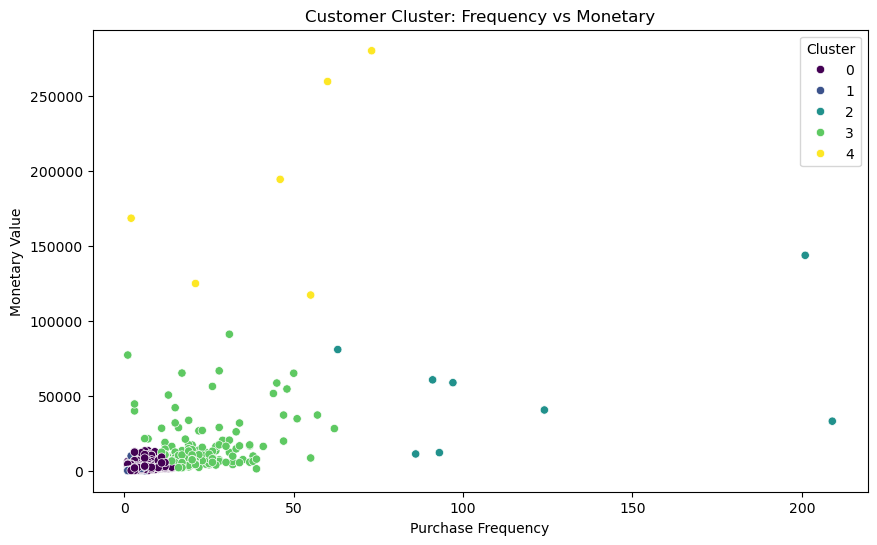

In [112]:
# Creating a scatter plot for Frequency and Monetary values
plt.figure(figsize=(10,6))

# Plotting customers based on their clusters
sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Cluster", palette="viridis")

# Adding chart title 
plt.title("Customer Cluster: Frequency vs Monetary")

# Adding x-axis label
plt.xlabel("Purchase Frequency")

# Adding y-axis label
plt.ylabel("Monetary Value")

# Displaying the chart
plt.show()

# 71. Display Final Cluster Summary

In [113]:
# Displaying the average RFM values for each customer cluster
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,42.918635,3.650262,1333.132908
1,247.469426,1.553151,478.648242
2,5.500000,120.500000,55099.491250
3,14.671362,21.286385,12813.941596
4,6.666667,42.833333,190808.536667


# CUSTOMER RECOMMENDATION SYSTEM

# 72. Create Customer-Product Matrix

In [114]:
# Creating a customer-product purchase matrix
customer_product = df.pivot_table(index="CustomerID", columns="Description", values="Quantity", aggfunc="sum", fill_value=0)

# Displaying the first five rows 
customer_product.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# 73. Check Matrix Shape

In [115]:
# Checking the number of customers and products
customer_product.shape

(4338, 3877)

# 74. Create Customer Similarity

In [117]:
# Importing cosine similarity for measuring customer similarity
from sklearn.metrics.pairwise import cosine_similarity

# Calculating similarity between customers
customer_similarity = cosine_similarity(customer_product)

# Converting similarity scores into a DataFrame
similarity_df = pd.DataFrame(customer_similarity, index=customer_product.index, columns=customer_product.index)

# Displaying the similarity matrix
similarity_df.head()

CustomerID,12346,12347,12348,12349,12350,12352,12353,12354,12355,12356,...,18273,18274,18276,18277,18278,18280,18281,18282,18283,18287
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
12347,0.0,1.000000,0.148879,0.020750,0.014435,0.028933,0.0,0.022843,0.506252,0.186107,...,0.0,0.001212,0.406837,0.0,0.015133,0.037236,0.0,0.010873,0.068608,0.108942
12348,0.0,0.148879,1.000000,0.000169,0.000315,0.001311,0.0,0.010634,0.286226,0.226244,...,0.0,0.032510,0.168665,0.0,0.000000,0.000000,0.0,0.000000,0.164841,0.110096
12349,0.0,0.020750,0.000169,1.000000,0.030121,0.077801,0.0,0.004931,0.000180,0.150819,...,0.0,0.148066,0.000000,0.0,0.015680,0.000000,0.0,0.013398,0.039266,0.005644
12350,0.0,0.014435,0.000315,0.030121,1.000000,0.001610,0.0,0.000000,0.000000,0.001179,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.020109,0.000000


# 75. Create Recommendation Function

In [119]:
# Creating a function to recommend products for a customer
def recommend_products(customer_id, num_recommendations=5):

    # Checking whether the customer exists
    if customer_id not in customer_product.index:
        return"Customer ID not found."

        # Finding similar customers
        similar_customers = similarity_df[customer_id].sort_values(ascending = False)

        # Removing the selected customer from the similarity list
        similar_customers = similar_customers.drop(customer_id)

        # Selecting the most similar customers
        top_customers = similar_customers.head(5).index

        # Getting products purchased by similar customers
        similar_customer_products = customer_product.loc[top_customers].sum()

        # Getting products already purchased by the selected customer
        purchased_products = customer_product.loc[customer_id]

        # Removing already purchased products
        recommendations = similar_customer_products[purchased_products==0]

        # Sorting products by popularity among similar customers
        recommendations = recommendations.sort_values(ascending=False)

        # Returning top recommendations
        return recommendations.head(num_recommendations)

# 76. Test the Recommendation System

In [120]:
# Selecting a sample customer ID 
sample_customer = customer_product.index[0]

# Displaying the sample customer ID
print("Sample Customer ID:", sample_customer)

Sample Customer ID: 12346


In [121]:
# Generating product recommendations for the sample customer
recommend_products(sample_customer, 5)

# BUSINESS INSIGHTS & CUSTOMER SEGMENT INTERPRETATION

# 77. Display Segment Performance

In [122]:
# Calculating average RFM values for each customer segment
segment_performance = rfm.groupby("CustomerSegment")[["Recency", "Frequency", "Monetary"]].mean()

# Displaying segment performance
segment_performance

,Recency,Frequency,Monetary
CustomerSegment,,,
At-Risk Customers,95.810265,3.108003,1112.184915
VIP Customers,14.136564,25.352423,19008.884185


# 78. Count Customers in Each Segment

In [123]:
# Counting the number of customers in each segment
segment_customer_count = rfm["CustomerSegment"].value_counts()

# Displaying customer count by segment
segment_customer_count

CustomerSegment
At-Risk Customers    4111
VIP Customers         227
Name: count, dtype: int64

# 79. Visualize Segment Size

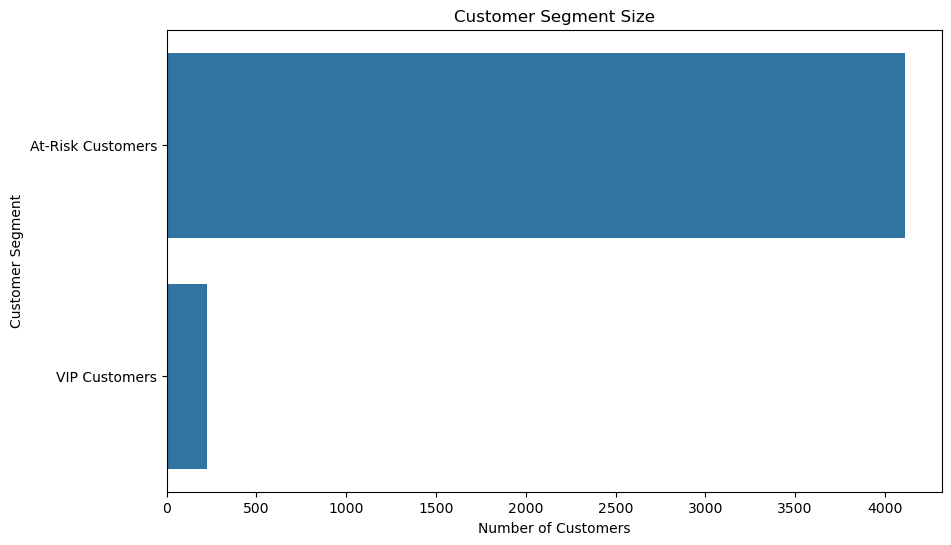

In [124]:
# Creating a bar chart for customer segment sizes
plt.figure(figsize=(10,6))

# Plotting the number of customers in each segment
sns.barplot(x=segment_customer_count.values, y=segment_customer_count.index)

# Adding chart title 
plt.title("Customer Segment Size")

# Adding x-axis label
plt.xlabel("Number of Customers")

# Adding y-axis label
plt.ylabel("Customer Segment")

# Displaying the chart
plt.show()

# 80. Visualize Monetary Value by Segment

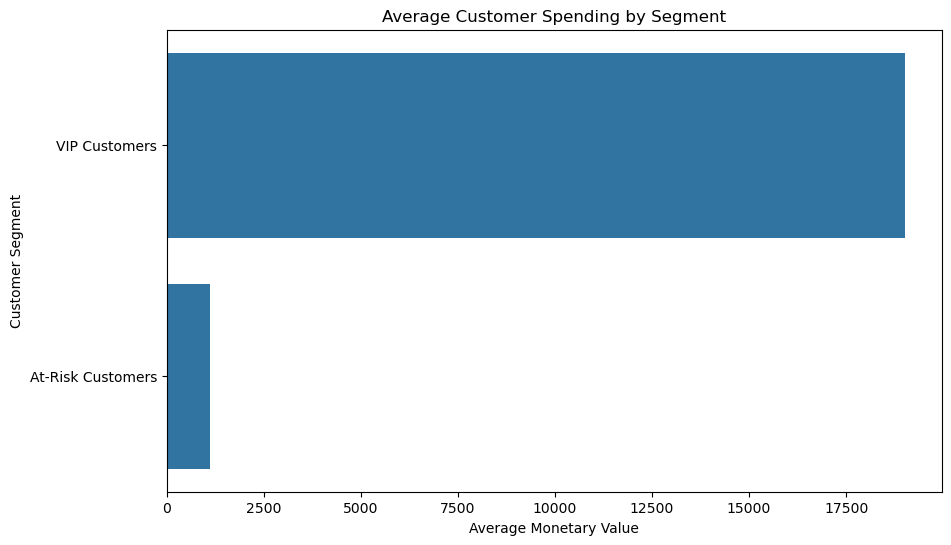

In [125]:
# Calculating average monetary value for each segment
segment_monetary = rfm.groupby("CustomerSegment")["Monetary"].mean().sort_values(ascending=False)

# Creating a bar chart
plt.figure(figsize=(10,6))

# Plotting average monetary value
sns.barplot(x=segment_monetary.values, y=segment_monetary.index)

# Adding chart title
plt.title("Average Customer Spending by Segment")

# Adding x-axis label
plt.xlabel("Average Monetary Value")

# Adding y-axis label
plt.ylabel("Customer Segment")

# Displaying the chart
plt.show()

# 81. Final Business Summary

In [126]:
# Displaying the final customer segment analysis
print("Customer Segmentation Business Insights")
print("------------------------------------------------------------")

# Displaying the num,ber of customers in each segment
for segment, count in segment_customer_count.items():
    print(f"{segment}:{count} costomers")

Customer Segmentation Business Insights
------------------------------------------------------------
At-Risk Customers:4111 costomers
VIP Customers:227 costomers


# 82. Final Conclusion

In [127]:
# Displaying the final project conclusion
print("Customer Segmentation and Recommendation System Using K-Means Clustering")
print("-----------------------------------------------------------------------")

print("This project successfully analyzed customer purchasing behavior using RFM analysis.")

print("K-Means clustering was used to segment customers into meaningful groups based on Recency, Frequency, and Monetary value.")

print("The Elbow Method and Silhouette Score were used to evaluate the clustering performance.")

print("A customer similarity-based recommendation system was also developed to suggest relevant products.")

print("The analysis provides useful business insights for customer retention, personalized marketing, and targeted promotions.")

print("Overall, this project demonstrates an end-to-end Data Science workflow from data cleaning and EDA to machine learning, customer segmentation, recommendation, and business insights.")

Customer Segmentation and Recommendation System Using K-Means Clustering
-----------------------------------------------------------------------
This project successfully analyzed customer purchasing behavior using RFM analysis.
K-Means clustering was used to segment customers into meaningful groups based on Recency, Frequency, and Monetary value.
The Elbow Method and Silhouette Score were used to evaluate the clustering performance.
A customer similarity-based recommendation system was also developed to suggest relevant products.
The analysis provides useful business insights for customer retention, personalized marketing, and targeted promotions.
Overall, this project demonstrates an end-to-end Data Science workflow from data cleaning and EDA to machine learning, customer segmentation, recommendation, and business insights.


# 83. Project Conclusion

 This project successfully demonstrates how Data Science and Machine Learning can be used to understand customer behavior and improve business decision-making. RFM analysis helped identify important customer characteristics, while K-Means Clustering divided customers into meaningful groups. The recommendation system further enhanced the project by suggesting relevant products based on customer similarity.


 Overall, the project provides a practical example of how customer segmentation and personalized recommendations can support customer retention, targeted marketing, personalized offers, and business growth.